# Homework 5: Hypotheses, and hypotheticals.

*Instructions:*
Please answer the following questions and submit your work
by editing this jupyter notebook and submitting it on Canvas.
Questions may involve math, programming, or neither,
but you should make sure to *explain your work*:
i.e., you should usually have a cell with at least a few sentences
explaining what you are doing.

Also, please be sure to always specify units of any quantities that have units,
and label axes of plots (again, with units when appropriate).

In [1]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
rng = np.random.default_rng()

# 1. Rain

Is it rainier in Eugene or Springfield?
In [`data/eug_spr_rain.csv`](data/eug_spr_rain.csv) you'll find data on daily rainfall, in inches,
at NOAA weather stations in Eugene on Queens East Street
and on Dixie Drive in Springfield.
You can read in the data as follows:

In [2]:
import pandas as pd
rain = pd.read_csv("eug_spr_rain.csv").set_index("date")
rain.head(10)

,eugene,springfield
date,,
2013-03-06,0.77,0.63
2013-03-07,0.18,0.29
2013-03-08,0.01,0.19
2013-03-12,0.00,0.00
2013-03-13,0.00,0.00
2013-03-14,0.00,0.00
2013-03-16,0.00,0.00
2013-03-17,0.08,0.16
2013-03-18,0.01,0.00


**(a)** Look at the data: make numerical or graphical summaries of the daily totals in each location,
and how they relate to each other.

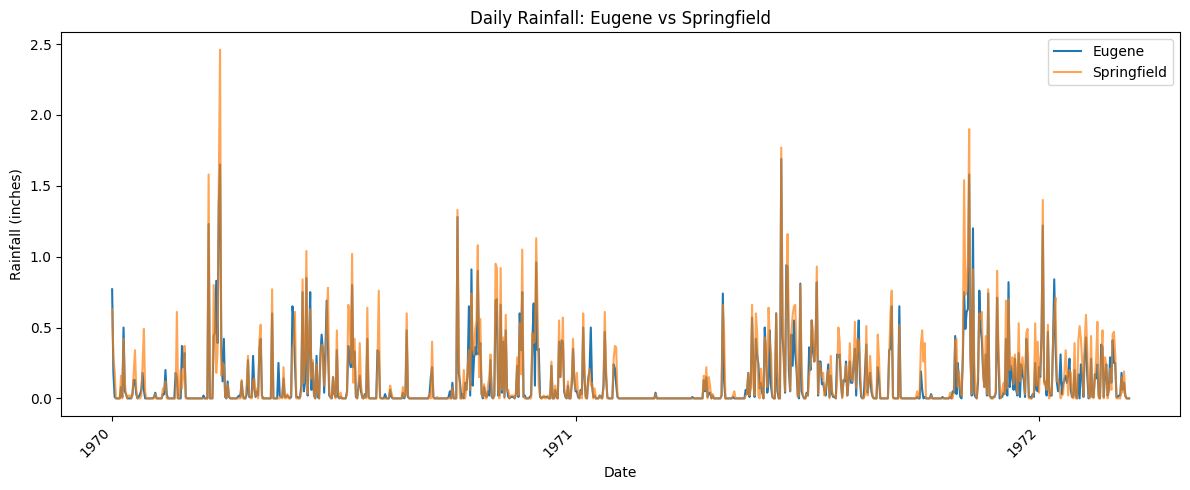

In [3]:
summary = rain[["eugene", "springfield"]].describe()
import matplotlib.dates as mdates

plt.figure(figsize=(12, 5))
plt.plot(rain['eugene'], label='Eugene')
plt.plot(rain['springfield'], label='Springfield', alpha=0.7)
plt.title("Daily Rainfall: Eugene vs Springfield")
plt.xlabel("Date")
plt.ylabel("Rainfall (inches)")
plt.legend()

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interpret:** When rain spikes in one city, it is likely to spike in the other city as well. There also seems to be a seasonal pattern, with more rain in the winter months (November to March) and less in the summer months (June to August). The rainfall in Eugene is generally higher than in Springfield, 
but there are days when Springfield has more rain.

**(b)** Compute the daily difference (Eugene minus Springfield) in rainfall,
    and summarize that distribution.


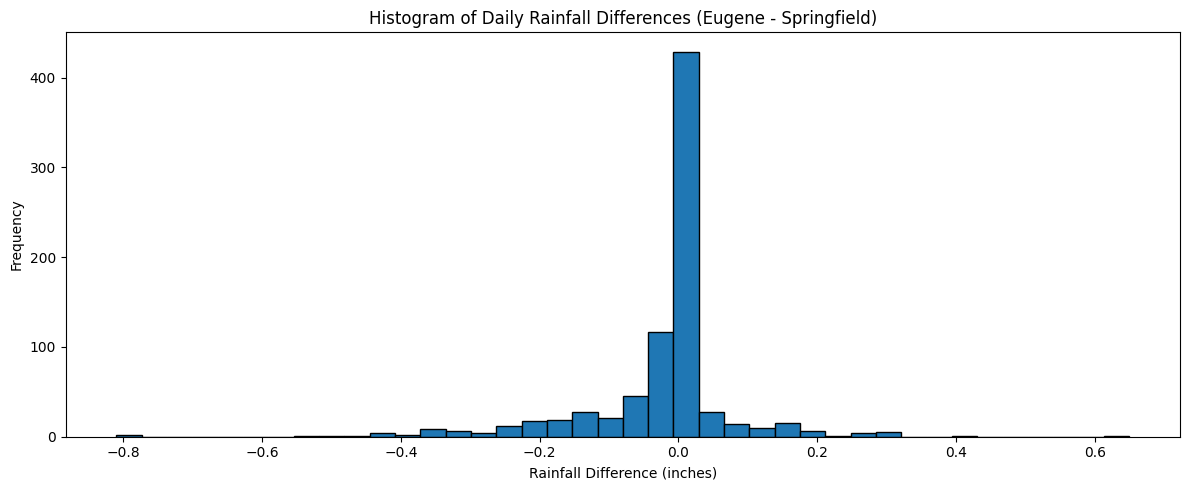

In [4]:
rain["diff"] = rain["eugene"] - rain["springfield"]
diff_summary = rain["diff"].describe()

plt.figure(figsize=(12, 5))
plt.hist(rain["diff"], bins=40, edgecolor='black')
plt.title("Histogram of Daily Rainfall Differences (Eugene - Springfield)")
plt.xlabel("Rainfall Difference (inches)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**What this sbows:** Most days Eugene and Springfield receive nearly identical rainfall, with differences clustering tightly around 0. The slight left skew suggests Springfield occasionally gets more rain than Eugene, but large differences are rare.


**(c)** On what proportion of the days did it rain more in Eugene than Springfield?
How about more in Springfield than in Eugene?



In [5]:
more_eugene = (rain["diff"] > 0).mean()
more_springfield = (rain["diff"] < 0).mean()
equal_rain = (rain["diff"] == 0).mean()


print(f"Days Eugene rainier:      {more_eugene:.3f} ({more_eugene*100:.1f}%)")
print(f"Days Springfield rainier: {more_springfield:.3f} ({more_springfield*100:.1f}%)")
print(f"Equal rainfall days:      {equal_rain:.3f} ({equal_rain*100:.1f}%)")


Days Eugene rainier:      0.232 (23.2%)
Days Springfield rainier: 0.360 (36.0%)
Equal rainfall days:      0.408 (40.8%)



**(d)** Compute the $t$ statistic for the Eugene minus Springfield difference,
    and get a $p$-value for the two-sided test
    (i.e., the probability that the $t$ distribution is larger
    in absolute value than the number you calculated).

In [6]:
n = len(rain["diff"])
mean_diff = rain["diff"].mean()
std_diff = rain["diff"].std(ddof=1)
t_stat = mean_diff / (std_diff / (n ** 0.5))
df = n - 1
p_value = 2 * scipy.stats.t.sf(abs(t_stat), df)

print(f"\nT-statistic: {t_stat:.4f}")
print(f"Degrees of freedom: {df}")
print(f"P-value: {p_value:.6f}")
print(f"Two-tailed p-value: {p_value:.2e}")


T-statistic: -6.6200
Degrees of freedom: 801
P-value: 0.000000
Two-tailed p-value: 6.58e-11


**(e)** What is your conclusion? Write a few sentences reporting the results,
including the statistical tests and real-world interpretations.
Be sure to include takeaways and context (e.g., what was the average rainfall?),
and address possible concerns (are any assumptions of the $t$ test likely violated)?

- Springfield gets slightly more rain than Eugene (~0.19 vs ~0.16 in/day), and this difference is statistically significant (t = −6.62, p ≈ 6.58e-11).
- 41% of days had equal rainfall. One concern is that daily rainfall isn't independent (rainy days cluster), which may inflate the t-statistic, but the large sample makes the conclusion reliable overall.

# 2. To the $t$

You now know a few facts about the [$t$ distribution](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html):
- The $t$ statistic, computed from a sample of $n$ independent draws from a distribution $X$ with mean $\mu$,
  is approximately described by Student's $t$ distribution with $n-1$ degrees of freedom.
- The previous statement is exact if $X$ is Normal.

In particular: define $t_*(n)$ so that a draw from Student's $t$ distribution with $n-1$ degrees of freedom
is larger than $t_*(n)$ with probability 95\%.
Then, if $X_1, \ldots, X_n$ are independent draws from some distribution with $t$ statistic $T$
calculated using the true mean of that distribution,
then $\mathbb{P}(T > t_*(n)) \approx 0.05$.
If $X_1, \ldots, X_n$ are draws from the Normal distribution then this is exact.

What does that "approximately" mean? You have the tools to find out.

*(a)* For values of $n$ between $n=2$ and $n=200$, draw $n$ samples from a Normal(mean=0, sd=1) distribution, and
compute the $t$ statistic. Do this 100,000 times and report what percentage of the time
these values are larger than $t_*(n)$. You should get values pretty close to 0.05 for all values of $n$.

*(b)* Do the same with an Exponential(1) distribution (remember to subtract $\mu=1$ when computing the $t$ statistic).

*(c)* Now, do the same as in part (a) but with $\mu=2$.

*(d)* Explain the practical consequence of (b) and (c) for someone who does a lot of $t$ tests:
which one tells you about false positive rates, and which one tells you about statistical power?

*Note:* in computing the $t$ statistic, be sure to use `np.std(..., ddof=1)`!
*Note:* To get $t_*(n)$ use `scipy.stats.t.ppf()`.

In [7]:
from scipy.stats import t
rng = np.random.default_rng(42)
ns = np.arange(2, 201)
sim_size = 100_000

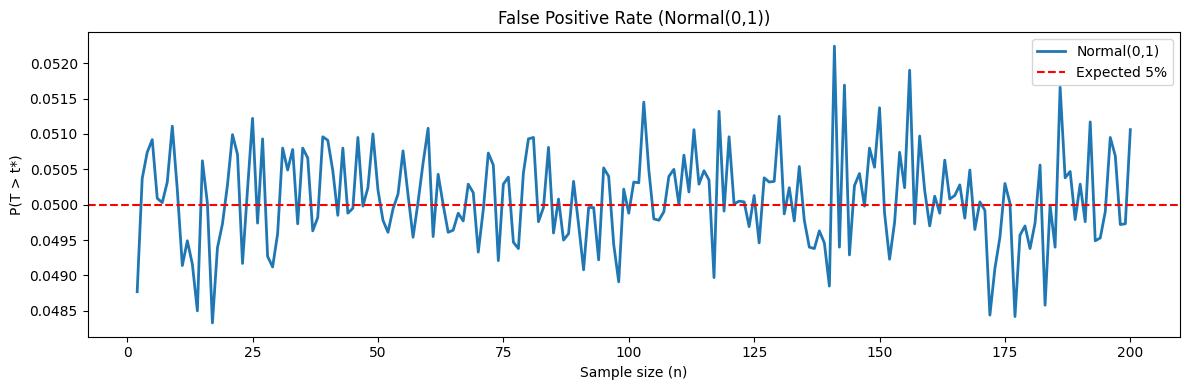

In [8]:
#2a
false_pos_normal = []
for n in ns:
    t_star = t.ppf(0.95, df=n-1)
    samples = rng.normal(0, 1, size=(sim_size, n))
    means = samples.mean(axis=1)
    stds = np.std(samples, axis=1, ddof=1)
    t_stats = means / (stds / np.sqrt(n))
    false_pos_normal.append(np.mean(t_stats > t_star))

plt.figure(figsize=(12, 4))
plt.plot(ns, false_pos_normal, label="Normal(0,1)", linewidth=2)
plt.axhline(0.05, color='red', linestyle='--', label="Expected 5%")
plt.title("False Positive Rate (Normal(0,1))")
plt.xlabel("Sample size (n)")
plt.ylabel("P(T > t*)")

plt.legend()
plt.tight_layout()
plt.show()

**Interpretaation** The false positive rate stays close to 5% for all sample sizes which
this confirms the t-test is exact for Normal data regardless of n.

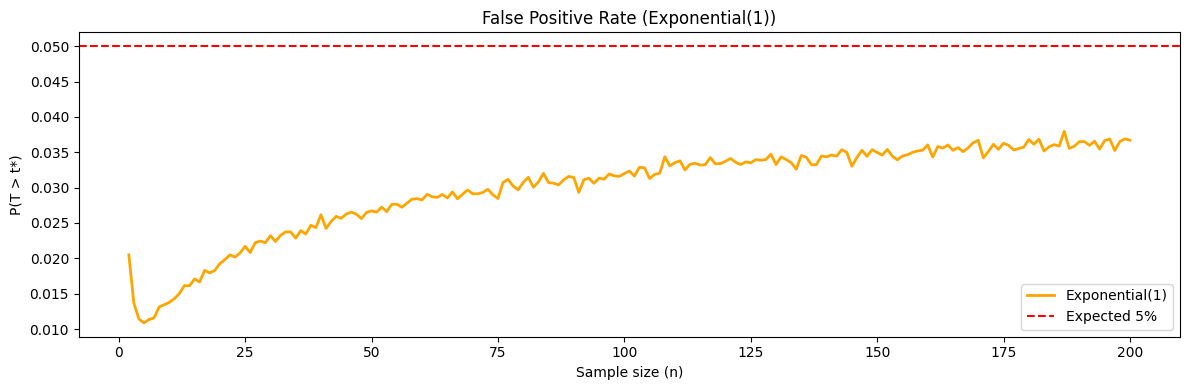

In [9]:
#2b
false_pos_exp = []
for n in ns:
    t_star = t.ppf(0.95, df=n-1)
    samples = rng.exponential(scale=1.0, size=(sim_size, n))
    means = samples.mean(axis=1)
    stds = np.std(samples, axis=1, ddof=1)
    t_stats = (means - 1) / (stds / np.sqrt(n))
    false_pos_exp.append(np.mean(t_stats > t_star))

plt.figure(figsize=(12, 4))
plt.plot(ns, false_pos_exp, label="Exponential(1)", color='orange', linewidth=2)
plt.axhline(0.05, color='red', linestyle='--', label="Expected 5%")
plt.title("False Positive Rate (Exponential(1))")
plt.xlabel("Sample size (n)")
plt.ylabel("P(T > t*)")

plt.legend()
plt.tight_layout()
plt.show()

**interpretation** With Exponential(1) data, the false positive rate stays below 5% for all n, 
reaching only ~3.5% even at n=200. This means the t-test rejects less often than it should, even as n grows larger.

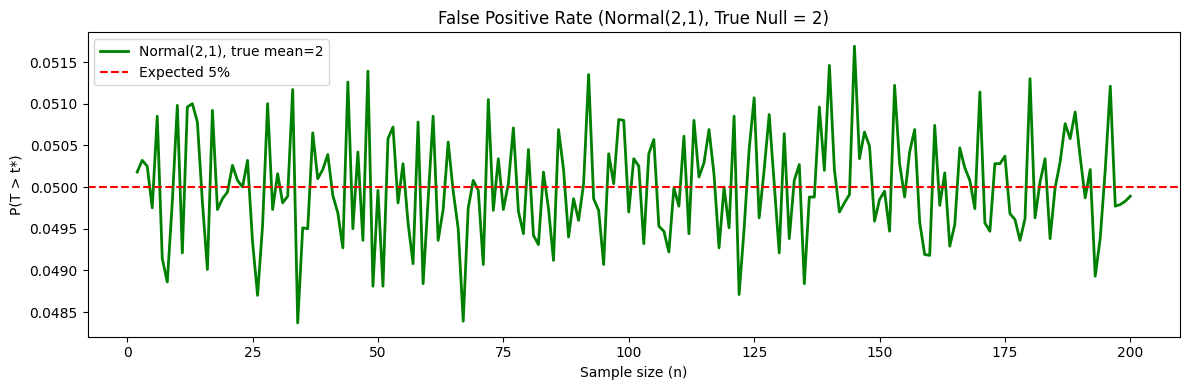

In [10]:
#2c
false_pos_shift = []
for n in ns:
    t_star = t.ppf(0.95, df=n-1)
    samples = rng.normal(loc=2, scale=1, size=(sim_size, n))
    means = samples.mean(axis=1)
    stds = np.std(samples, axis=1, ddof=1)
    t_stats = (means - 2) / (stds / np.sqrt(n))
    false_pos_shift.append(np.mean(t_stats > t_star))

plt.figure(figsize=(12, 4))
plt.plot(ns, false_pos_shift, label="Normal(2,1), true mean=2", color='green', linewidth=2)
plt.axhline(0.05, color='red', linestyle='--', label="Expected 5%")
plt.title("False Positive Rate (Normal(2,1), True Null = 2)")
plt.xlabel("Sample size (n)")
plt.ylabel("P(T > t*)")

plt.legend()
plt.tight_layout()
plt.show()

Interpret: this shows the test is correctly calibrated. In a real scenario where 
μ≠null hypothesis value, the rate would *rise above* 5%, which is exactly what power measures: 
how often you correctly reject a false null hypothesis.

#### 2d

- Part (b) tells you about **false positive rates** — when data is skewed (non-normal), 
the t-test is overly conservative, rejecting too rarely (~1-3% instead of 5%). 
- Part (c) tells you about **statistical power** — when the null hypothesis is true, 
the rate correctly stays at ~5% regardless of n. 
> takeaway: t-tests on skewed data with small samples may not behave as expected, 
but a large n fixes this via the CLT.

# 3. Imaginary data

Make up a situation in which we'd have measured at least 3 quantitative variables
in at least 500 observations.
You should have some positively correlated pairs of variables and some negatively correlated pairs.
It does not have to be realistic or serious.

*(a)* Describe it in words.

- Books read per year: How many books a student reads recreationally. Avid readers might log in 30+, casual readers fewer.
- GPA (0–4.0): Academic performance. We expect students who read more to perform better academically.
- Hours spent on social media per day: Students on social media more may read less and have lower GPAs.

*(b)* Simulate some data that looks at least roughly like what you'd expect
    real data to look like.
    
*(c)* Make plots of the data: histograms of each variable,
    and scatter plots of each pair of variables.

*(d)* Compute the correlations between each of your simulated variables
    (with `np.corrcoef( )`)
    and explain why correlations are positive or negative.

*Note*: By "looks at least roughly like you'd expect",
I mean that variables should be in *real units* and not totally unreasonable values.
So, counts should be actually integers,
weights should not be negative numbers,
etcetera.
For instance, if one of your variable is "number of pieces of candy obtained by a trick-or-treater",
then these should be nonnegative integers,
and should not be in the millions.
(If it's in the thousands, that's probably not realistic, but close enough.)

In [14]:
#3b
rng = np.random.default_rng(42)
n = 500

# Books read per year 
books = rng.normal(loc=15, scale=6, size=n)
books = np.round(np.clip(books, 0, 50)).astype(int)

# Social media hours per day (negatively correlated with books)
social_media = 6 - 0.08 * books + rng.normal(0, 1.2, size=n)
social_media = np.clip(social_media, 0, 12)

# GPA: positively correlated with books, negatively with social media
GPA = 2.5 + 0.03 * books - 0.08 * social_media + rng.normal(0, 0.2, size=n)
GPA = np.clip(GPA, 0, 4.0)

book_df = pd.DataFrame({
    "books_per_year": books,
    "social_media_hours": social_media,
    "GPA": GPA
})

book_df.head(10)


,books_per_year,social_media_hours,GPA
0,17,6.276635,2.496013
1,9,6.354222,2.115805
2,20,3.536624,2.734175
3,21,2.516996,3.055422
4,3,2.202565,2.414393
5,7,4.787805,2.395018
6,16,7.624498,2.504056
7,13,5.481861,2.376483
8,15,4.128513,2.770969
9,10,5.758096,2.415121


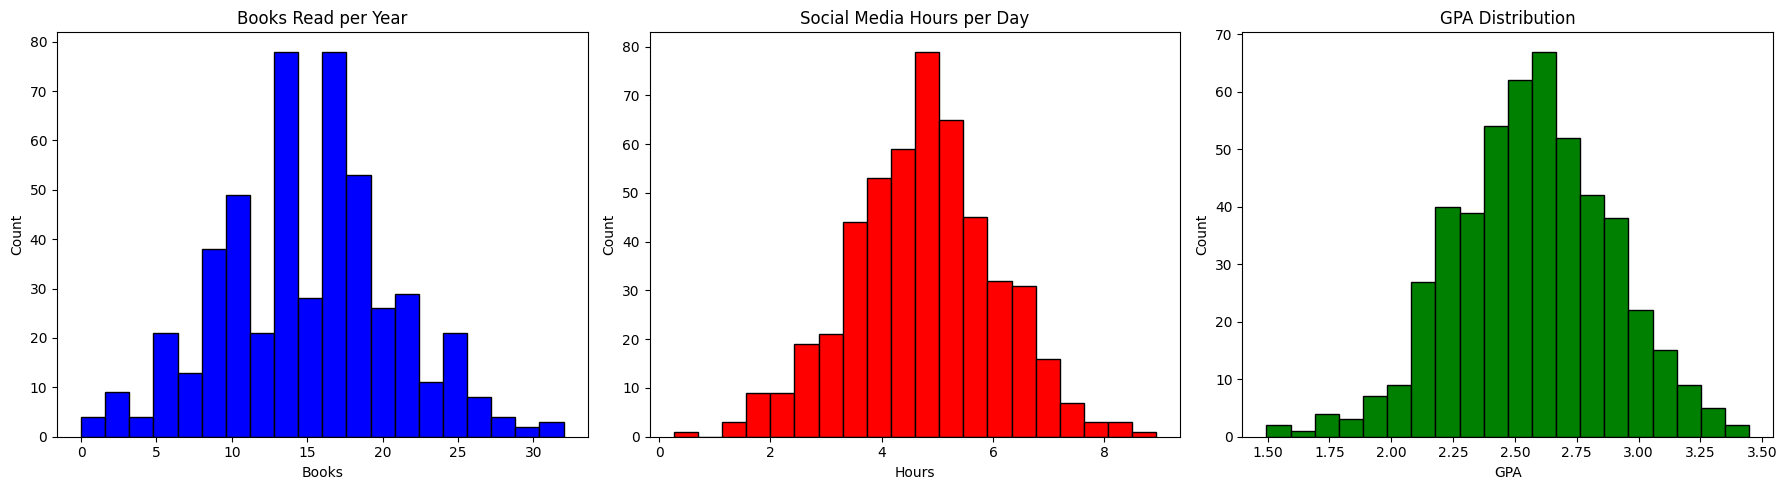

In [22]:
#3c histogram
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.hist(book_df["books_per_year"], bins=20, color="blue", edgecolor="black")
plt.title("Books Read per Year")
plt.xlabel("Books")
plt.ylabel("Count")

plt.subplot(1, 3, 2)
plt.hist(book_df["social_media_hours"], bins=20, color="red", edgecolor="black")
plt.title("Social Media Hours per Day")
plt.xlabel("Hours")
plt.ylabel("Count")

plt.subplot(1, 3, 3)
plt.hist(book_df["GPA"], bins=20, color="green", edgecolor="black")
plt.title("GPA Distribution")
plt.xlabel("GPA")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

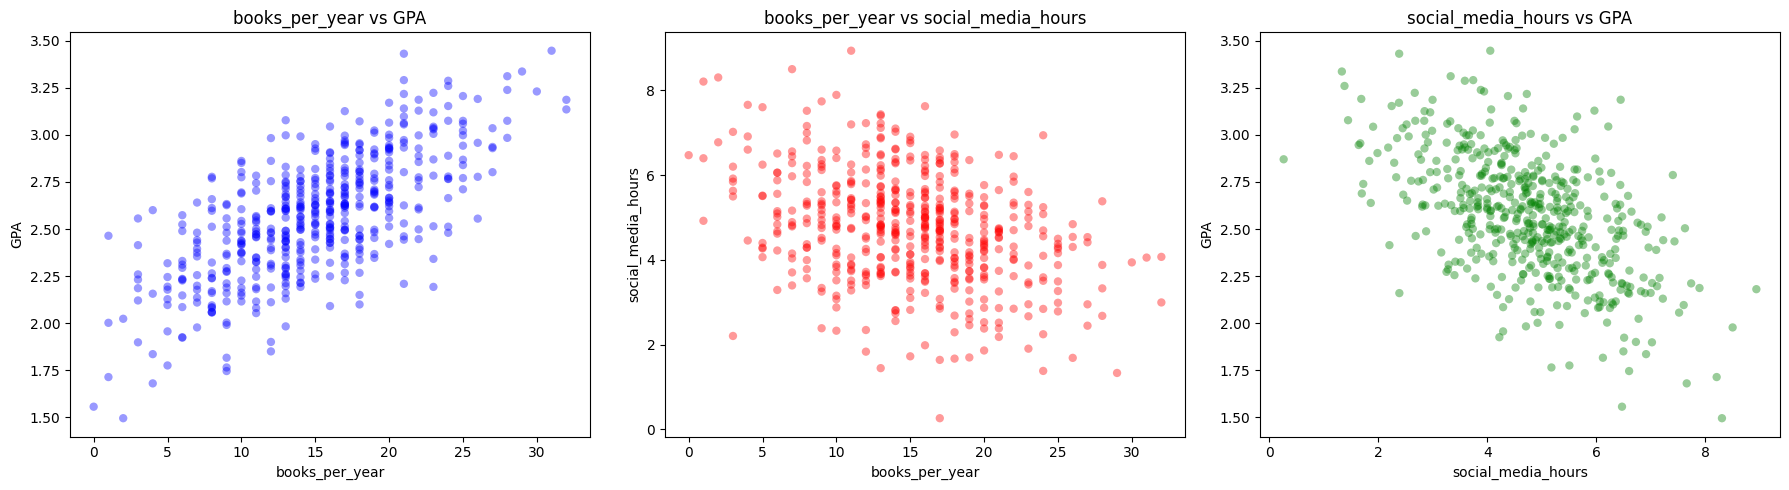

In [25]:
#3c scatter
pairs = [
    ("books_per_year", "GPA", "blue"),
    ("books_per_year", "social_media_hours", "red"),
    ("social_media_hours", "GPA", "green")
]

plt.figure(figsize=(18, 5))

for i, (x, y, c) in enumerate(pairs):
    plt.subplot(1, 3, i+1)
    plt.scatter(book_df[x], book_df[y], alpha=0.4, color=c, edgecolors='none')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

In [26]:
#3d
corr_matrix = np.corrcoef([
    book_df["books_per_year"],
    book_df["social_media_hours"],
    book_df["GPA"]
])

print("Correlation Matrix:")
print(f"                      books   social_media   GPA")
print(f"books_per_year        {corr_matrix[0,0]:.2f}       {corr_matrix[0,1]:.2f}         {corr_matrix[0,2]:.2f}")
print(f"social_media_hours    {corr_matrix[1,0]:.2f}       {corr_matrix[1,1]:.2f}         {corr_matrix[1,2]:.2f}")
print(f"GPA                   {corr_matrix[2,0]:.2f}       {corr_matrix[2,1]:.2f}         {corr_matrix[2,2]:.2f}")

Correlation Matrix:
                      books   social_media   GPA
books_per_year        1.00       -0.36         0.69
social_media_hours    -0.36       1.00         -0.56
GPA                   0.69       -0.56         1.00


#### 3d
- Books and GPA have a strong positive correlation (r = 0.69) — students who read more 
tend to have higher GPAs, likely due to better comprehension and study habits.
- Social media and GPA are negatively correlated (r = -0.56) — more screen time competes with studying, 
pulling grades down.
- Books and social media are negatively correlated (r = -0.36) — 
students who read more simply spend less time on social media.